# Assignment 4: offensive language detection in-domain and cross-domain (Group 3)

Four models, each trained twice and evaluated on `olid-test.csv`:
- **In-domain:** train on `olid-train-small.csv`
- **Cross-domain:** train on `hasoc-train.csv`

Models: HateBERT and fBERT (fine-tuned with the simpletransformers default hyperparameters), Logistic Regression on TF-IDF features, and a CNN (5 seeds). The notebook ends with the error analysis used in the report.

Fine-tuned transformers are cached in `models/`, predictions in `results/`. If a prediction file exists, it is loaded instead of training again; delete it to rerun.

**Setup (macOS):**
```bash
python3.13 -m venv venv-a4
source venv-a4/bin/activate
pip install torch transformers accelerate tensorflow scikit-learn pandas matplotlib ipykernel
```

In [1]:
import os
import re
import json
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

/Users/justus/Desktop/projects/subjective-assignment-3/venv-a4/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [2]:
SEED = 42
MAX_SEQ_LENGTH = 512
EVAL_BATCH_SIZE = 100

# simpletransformers ClassificationArgs defaults
TRAINING_ARGS = dict(
    num_train_epochs=1,
    learning_rate=4e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=1,
    warmup_steps=0.06,
    lr_scheduler_type="linear",
    weight_decay=0.0,
    adam_epsilon=1e-8,
    adam_beta1=0.9,
    adam_beta2=0.999,
    max_grad_norm=1.0,
    optim="adamw_torch",
    seed=SEED,
)

CNN_SEEDS = [0, 1, 2, 3, 4]

os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## Data

In [3]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)


In [4]:
# Same lowercasing and punctuation stripping as the default TextVectorization layer of the CNN
PUNCTUATION = re.compile(r"""[!"#$%&()\*\+,\-\./:;<=>?@\[\\\]^_`{|}~']""")


def simple_tokens(text):
    return PUNCTUATION.sub("", str(text).lower()).split()


datasets = {
    "OLID train (small)": olid_train,
    "HASOC train": hasoc_train,
    "OLID test": olid_test,
}
test_tokens = [token for tweet in olid_test["text"].map(simple_tokens) for token in tweet]

stat_rows = []
for name, df in datasets.items():
    texts = df["text"].astype(str)
    tokens = texts.map(simple_tokens)
    counts = Counter(token for tweet in tokens for token in tweet)

    row = {
        "Dataset": name,
        "Messages": len(df),
        "OFF share": df["labels"].mean(),
        "Mean tokens": tokens.map(len).mean(),
        "Median tokens": tokens.map(len).median(),
        "With @USER placeholder": texts.str.contains("@USER").mean(),
        "With real @handle": texts.str.contains(r"@(?!USER)\w").mean(),
        "With URL placeholder": texts.str.contains(r"\bURL\b").mean(),
        "With hashtag": texts.str.contains("#").mean(),
        "Vocabulary size": len(counts),
    }
    if name != "OLID test":
        vocab = {token for token, _ in counts.most_common(20000)}
        row["Test tokens unseen in this train set"] = np.mean([token not in vocab for token in test_tokens])
    stat_rows.append(row)

display(pd.DataFrame(stat_rows).set_index("Dataset").T.round(3))

print("Most frequent content words:")
for name, df in datasets.items():
    counts = Counter(
        token
        for tweet in df["text"].map(simple_tokens)
        for token in tweet
        if token not in ENGLISH_STOP_WORDS and token not in {"user", "url"} and len(token) > 2
    )
    print(f"{name:20}", ", ".join(token for token, _ in counts.most_common(20)))

print("\nDuplicate texts in HASOC train:", hasoc_train["text"].duplicated().sum())
print("OLID test tweets also in OLID train:", len(set(olid_test["text"]) & set(olid_train["text"])))

Dataset,OLID train (small),HASOC train,OLID test
Messages,5852.000,5852.000,860.000
OFF share,0.386,0.386,0.279
Mean tokens,22.325,23.061,24.151
Median tokens,18.000,21.000,22.000
With @USER placeholder,0.927,0.000,0.385
With real @handle,0.000,0.515,0.000
With URL placeholder,0.140,0.000,0.559
With hashtag,0.143,0.984,0.738
Vocabulary size,13730.000,18971.000,5503.000
Test tokens unseen in this train set,0.124,0.201,NaN


Most frequent content words:
OLID train (small)   gun, liberals, control, like, antifa, just, maga, conservatives, people, know, trump, amp, dont, think, good, right, shit, going, time, need
HASOC train          fucktrump, trumpisatraitor, icc, realdonaldtrump, doctorsfightback, trump, shameonicc, dhonikeepstheglove, doctors, amp, borisjohnsonshouldnotbepm, murderer, people, just, world, like, rapist, douchebag, resist, india
OLID test            liberals, conservatives, antifa, just, like, gun, control, maga, people, trump, dont, want, love, know, good, going, new, democrats, need, way

Duplicate texts in HASOC train: 78
OLID test tweets also in OLID train: 3


## Evaluation

In [5]:
def compute_metrics(results, experiment_name):
    y_test = results["labels"]
    predictions = results["prediction"]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1],
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy_score(y_test, predictions)
    }

    return metrics, confusion_matrix(y_test, predictions, labels=[0, 1])


def plot_confusion_matrices(cm_olid, cm_hasoc, model_name, path, values_format="d"):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    for ax, cm, title in [
        (axes[0], cm_olid, f"{model_name} - In-domain"),
        (axes[1], cm_hasoc, f"{model_name} - Cross-domain")
    ]:
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NOT", "OFF"]).plot(
            ax=ax, colorbar=False, values_format=values_format
        )
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()

## Transformers: HateBERT and fBERT

In [6]:
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer):
        self.encodings = tokenizer(list(df["text"]), truncation=True, max_length=MAX_SEQ_LENGTH)
        self.labels = list(df["labels"])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.encodings.items()}
        item["labels"] = self.labels[i]
        return item


def train_transformer(model_name, train_df, model_dir):
    if os.path.exists(os.path.join(model_dir, "config.json")):
        print(f"{model_dir} exists, skipping training")
        return

    # Always start from the base checkpoint
    set_seed(SEED)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = TrainingArguments(
        output_dir=model_dir,
        save_strategy="no",
        logging_steps=50,
        report_to="none",
        dataloader_pin_memory=False,
        **TRAINING_ARGS,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=TextDataset(train_df, tokenizer),
        data_collator=DataCollatorWithPadding(tokenizer),
    )

    start = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - start

    trainer.save_model(model_dir)
    tokenizer.save_pretrained(model_dir)

    with open(os.path.join(model_dir, "train_info.json"), "w") as f:
        json.dump({"device": str(trainer.args.device), "train_seconds": round(train_seconds, 1)}, f)
    print(f"Trained on {trainer.args.device} in {train_seconds / 60:.1f} min")


@torch.no_grad()
def predict_transformer(model_dir, test_df):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()

    predictions = []
    for i in range(0, len(test_df), EVAL_BATCH_SIZE):
        batch = tokenizer(
            list(test_df["text"].iloc[i:i + EVAL_BATCH_SIZE]),
            truncation=True,
            max_length=MAX_SEQ_LENGTH,
            padding=True,
            return_tensors="pt"
        ).to(DEVICE)
        predictions.append(model(**batch).logits.argmax(dim=-1).cpu().numpy())

    return np.concatenate(predictions)


def run_transformer(model_name, train_df, test_df, experiment_name, model_dir, predictions_path):

    if os.path.exists(predictions_path):
        print(f"{predictions_path} exists, loading saved predictions")
        results = pd.read_csv(predictions_path)
    else:
        train_transformer(model_name, train_df, model_dir)
        results = test_df.copy()
        results["prediction"] = predict_transformer(model_dir, test_df)
        results["prediction_label"] = results["prediction"].map({0: "NOT", 1: "OFF"})
        results.to_csv(predictions_path, index=False)

    metrics, cm = compute_metrics(results, experiment_name)
    return results, metrics, cm

In [7]:
hb_olid_results, hb_olid_metrics, hb_cm_olid = run_transformer(
    "GroNLP/hateBERT",
    olid_train,
    olid_test,
    "In-domain: OLID → OLID",
    "models/hatebert-in-domain",
    "results/hatebert_in-domain_predictions.csv"
)

hb_hasoc_results, hb_hasoc_metrics, hb_cm_hasoc = run_transformer(
    "GroNLP/hateBERT",
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID",
    "models/hatebert-cross-domain",
    "results/hatebert_cross-domain_predictions.csv"
)

results/hatebert_in-domain_predictions.csv exists, loading saved predictions


results/hatebert_cross-domain_predictions.csv exists, loading saved predictions


In [8]:
# diptanu/fBERT mirrors the original fBERT (Sarkar et al., 2021), whose hub repository is no longer available
fb_olid_results, fb_olid_metrics, fb_cm_olid = run_transformer(
    "diptanu/fBERT",
    olid_train,
    olid_test,
    "In-domain: OLID → OLID",
    "models/fbert-in-domain",
    "results/fbert_in-domain_predictions.csv"
)

fb_hasoc_results, fb_hasoc_metrics, fb_cm_hasoc = run_transformer(
    "diptanu/fBERT",
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID",
    "models/fbert-cross-domain",
    "results/fbert_cross-domain_predictions.csv"
)

results/fbert_in-domain_predictions.csv exists, loading saved predictions
results/fbert_cross-domain_predictions.csv exists, loading saved predictions


## Logistic Regression

In [9]:
def run_logistic_regression(train_df, test_df, experiment_name):

    model = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ])

    model.fit(train_df["text"], train_df["labels"])

    results = test_df.copy()
    results["prediction"] = model.predict(test_df["text"])

    metrics, cm = compute_metrics(results, experiment_name)
    return model, results, metrics, cm


lr_olid, lr_olid_results, lr_olid_metrics, lr_cm_olid = run_logistic_regression(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID"
)

lr_hasoc, lr_hasoc_results, lr_hasoc_metrics, lr_cm_hasoc = run_logistic_regression(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID"
)

lr_olid_results.to_csv("results/lr_in-domain_predictions.csv", index=False)
lr_hasoc_results.to_csv("results/lr_cross-domain_predictions.csv", index=False)

## CNN

In [10]:
def train_predict_cnn(train_df, test_df, seed):
    tf.keras.utils.set_random_seed(seed)

    # Stratified dev split for early stopping, taken from the training data only
    train_part, dev_part = train_test_split(
        train_df, test_size=0.1, stratify=train_df["labels"], random_state=seed
    )

    X_train = tf.constant(train_part["text"].astype(str).tolist())
    y_train = train_part["labels"].values
    X_dev = tf.constant(dev_part["text"].astype(str).tolist())
    y_dev = dev_part["labels"].values
    X_test = tf.constant(test_df["text"].astype(str).tolist())

    vectorizer = TextVectorization(
        max_tokens=20000,
        output_sequence_length=100
    )
    vectorizer.adapt(X_train)

    model = Sequential([
        vectorizer,
        Embedding(20000, 128),
        Conv1D(128, 5, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_dev, y_dev),
        epochs=20,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    probabilities = model.predict(X_test, verbose=0).flatten()

    results = test_df.copy()
    results["probability"] = probabilities
    results["prediction"] = (probabilities >= 0.5).astype(int)
    results["seed"] = seed
    results["best_epoch"] = int(np.argmin(history.history["val_loss"])) + 1
    results["epochs_run"] = len(history.history["val_loss"])
    return results


def run_cnn(train_df, test_df, experiment_name, predictions_prefix):
    runs, seed_metrics, seed_cms = [], [], []

    for seed in CNN_SEEDS:
        path = f"{predictions_prefix}_seed{seed}.csv"

        if os.path.exists(path):
            print(f"{path} exists, loading saved predictions")
            results = pd.read_csv(path)
        else:
            results = train_predict_cnn(train_df, test_df, seed)
            results.to_csv(path, index=False)
            print(f"Seed {seed}: best epoch {results['best_epoch'].iloc[0]}, saved to {path}")

        metrics, cm = compute_metrics(results, experiment_name)
        metrics["Seed"] = seed
        runs.append(results)
        seed_metrics.append(metrics)
        seed_cms.append(cm)

    seed_metrics = pd.DataFrame(seed_metrics)
    mean_metrics = seed_metrics.drop(columns=["Experiment", "Seed"]).mean().to_dict()
    return runs, seed_metrics, {"Experiment": experiment_name, **mean_metrics}, np.mean(seed_cms, axis=0)

In [11]:
cnn_olid_runs, cnn_olid_seeds, cnn_olid_metrics, cnn_cm_olid = run_cnn(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID",
    "results/cnn_predictions_in_domain"
)

cnn_hasoc_runs, cnn_hasoc_seeds, cnn_hasoc_metrics, cnn_cm_hasoc = run_cnn(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID",
    "results/cnn_predictions_cross_domain"
)

pd.concat([cnn_olid_seeds, cnn_hasoc_seeds]).set_index(["Experiment", "Seed"]).round(4)

results/cnn_predictions_in_domain_seed0.csv exists, loading saved predictions
results/cnn_predictions_in_domain_seed1.csv exists, loading saved predictions
results/cnn_predictions_in_domain_seed2.csv exists, loading saved predictions
results/cnn_predictions_in_domain_seed3.csv exists, loading saved predictions
results/cnn_predictions_in_domain_seed4.csv exists, loading saved predictions
results/cnn_predictions_cross_domain_seed0.csv exists, loading saved predictions
results/cnn_predictions_cross_domain_seed1.csv exists, loading saved predictions
results/cnn_predictions_cross_domain_seed2.csv exists, loading saved predictions
results/cnn_predictions_cross_domain_seed3.csv exists, loading saved predictions
results/cnn_predictions_cross_domain_seed4.csv exists, loading saved predictions


NOT Precision  NOT Recall  NOT F1  \
Experiment                 Seed                                      
In-domain: OLID → OLID     0            0.8271      0.9258  0.8737   
                           1            0.8239      0.9129  0.8661   
                           2            0.8402      0.8903  0.8645   
                           3            0.8457      0.9016  0.8728   
                           4            0.8435      0.8516  0.8475   
Cross-domain: HASOC → OLID 0            0.7831      0.7452  0.7636   
                           1            0.7561      0.8548  0.8024   
                           2            0.7686      0.5677  0.6531   
                           3            0.7845      0.5403  0.6399   
                           4            0.7919      0.5032  0.6154   

                                 OFF Precision  OFF Recall  OFF F1  \
Experiment                 Seed                                      
In-domain: OLID → OLID     0            0.7229      0.5000  0.5911   
                           1            0.6879      0.4958  0.5763   
                           2            0.6650      0.5625  0.6095   
                           3            0.6935      0.5750  0.6287   
                           4            0.6068      0.5917  0.5992   
Cross-domain: HASOC → OLID 0            0.4148      0.4667  0.4392   
                           1            0.4340      0.2875  0.3459   
                           2            0.3333      0.5583  0.4174   
                           3            0.3418      0.6167  0.4398   
                           4            0.3391      0.6583  0.4476   

                                 Macro Precision  Macro Recall  Macro F1  \
Experiment                 Seed                                            
In-domain: OLID → OLID     0              0.7750        0.7129    0.7324   
                           1              0.7559        0.7044    0.7212   
                           2              0.7526        0.7264    0.7370   
                           3              0.7696        0.7383    0.7507   
                           4              0.7251        0.7216    0.7233   
Cross-domain: HASOC → OLID 0              0.5989        0.6059    0.6014   
                           1              0.5950        0.5712    0.5741   
                           2              0.5509        0.5630    0.5353   
                           3              0.5632        0.5785    0.5399   
                           4              0.5655        0.5808    0.5315   

                                 Accuracy  
Experiment                 Seed            
In-domain: OLID → OLID     0       0.8070  
                           1       0.7965  
                           2       0.7988  
                           3       0.8105  
                           4       0.7791  
Cross-domain: HASOC → OLID 0       0.6674  
                           1       0.6965  
                           2       0.5651  
                           3       0.5616  
                           4       0.5465

## Results

In [12]:
MODELS = {
    "fBERT": (fb_olid_metrics, fb_hasoc_metrics, fb_cm_olid, fb_cm_hasoc),
    "HateBERT": (hb_olid_metrics, hb_hasoc_metrics, hb_cm_olid, hb_cm_hasoc),
    "Logistic Regression": (lr_olid_metrics, lr_hasoc_metrics, lr_cm_olid, lr_cm_hasoc),
    "CNN": (cnn_olid_metrics, cnn_hasoc_metrics, cnn_cm_olid, cnn_cm_hasoc),
}

comparison = pd.DataFrame([
    {"Model": name, **metrics}
    for name, (olid_metrics, hasoc_metrics, _, _) in MODELS.items()
    for metrics in [olid_metrics, hasoc_metrics]
])

comparison.set_index(["Model", "Experiment"]).round(3)

NOT Precision  NOT Recall  \
Model               Experiment                                              
fBERT               In-domain: OLID → OLID              0.893       0.898   
                    Cross-domain: HASOC → OLID          0.865       0.958   
HateBERT            In-domain: OLID → OLID              0.885       0.918   
                    Cross-domain: HASOC → OLID          0.836       0.952   
Logistic Regression In-domain: OLID → OLID              0.802       0.948   
                    Cross-domain: HASOC → OLID          0.780       0.774   
CNN                 In-domain: OLID → OLID              0.836       0.896   
                    Cross-domain: HASOC → OLID          0.777       0.642   

                                                NOT F1  OFF Precision  \
Model               Experiment                                          
fBERT               In-domain: OLID → OLID       0.895          0.733   
                    Cross-domain: HASOC → OLID   0.909          0.850   
HateBERT            In-domain: OLID → OLID       0.901          0.765   
                    Cross-domain: HASOC → OLID   0.890          0.805   
Logistic Regression In-domain: OLID → OLID       0.869          0.748   
                    Cross-domain: HASOC → OLID   0.777          0.429   
CNN                 In-domain: OLID → OLID       0.865          0.675   
                    Cross-domain: HASOC → OLID   0.695          0.373   

                                                OFF Recall  OFF F1  \
Model               Experiment                                       
fBERT               In-domain: OLID → OLID           0.721   0.727   
                    Cross-domain: HASOC → OLID       0.612   0.712   
HateBERT            In-domain: OLID → OLID           0.692   0.726   
                    Cross-domain: HASOC → OLID       0.517   0.629   
Logistic Regression In-domain: OLID → OLID           0.396   0.518   
                    Cross-domain: HASOC → OLID       0.438   0.433   
CNN                 In-domain: OLID → OLID           0.545   0.601   
                    Cross-domain: HASOC → OLID       0.518   0.418   

                                                Macro Precision  Macro Recall  \
Model               Experiment                                                  
fBERT               In-domain: OLID → OLID                0.813         0.810   
                    Cross-domain: HASOC → OLID            0.857         0.785   
HateBERT            In-domain: OLID → OLID                0.825         0.805   
                    Cross-domain: HASOC → OLID            0.820         0.734   
Logistic Regression In-domain: OLID → OLID                0.775         0.672   
                    Cross-domain: HASOC → OLID            0.605         0.606   
CNN                 In-domain: OLID → OLID                0.756         0.721   
                    Cross-domain: HASOC → OLID            0.575         0.580   

                                                Macro F1  Accuracy  
Model               Experiment                                      
fBERT               In-domain: OLID → OLID         0.811     0.849  
                    Cross-domain: HASOC → OLID     0.810     0.862  
HateBERT            In-domain: OLID → OLID         0.814     0.855  
                    Cross-domain: HASOC → OLID     0.760     0.830  
Logistic Regression In-domain: OLID → OLID         0.693     0.794  
                    Cross-domain: HASOC → OLID     0.605     0.680  
CNN                 In-domain: OLID → OLID         0.733     0.798  
                    Cross-domain: HASOC → OLID     0.556     0.607

In [13]:
drop_rows = []
for name, (olid_metrics, hasoc_metrics, _, _) in MODELS.items():
    drop = olid_metrics["Macro F1"] - hasoc_metrics["Macro F1"]
    drop_rows.append({
        "Model": name,
        "In-domain Macro F1": olid_metrics["Macro F1"],
        "Cross-domain Macro F1": hasoc_metrics["Macro F1"],
        "Absolute drop": drop,
        "Relative drop (%)": drop / olid_metrics["Macro F1"] * 100
    })

display(pd.DataFrame(drop_rows).set_index("Model").round(4))

cnn_paired_drop = cnn_olid_seeds["Macro F1"].values - cnn_hasoc_seeds["Macro F1"].values
print(f"CNN absolute drop per seed: {cnn_paired_drop.mean():.4f} ± {cnn_paired_drop.std(ddof=1):.4f}, "
      f"lower cross-domain in {(cnn_paired_drop > 0).sum()} of {len(CNN_SEEDS)} seeds")

,In-domain Macro F1,Cross-domain Macro F1,Absolute drop,Relative drop (%)
Model,,,,
fBERT,0.8112,0.8104,0.0008,0.0970
HateBERT,0.8138,0.7597,0.0541,6.6464
Logistic Regression,0.6934,0.6052,0.0883,12.7316
CNN,0.7329,0.5564,0.1765,24.0806


CNN absolute drop per seed: 0.1765 ± 0.0353, lower cross-domain in 5 of 5 seeds


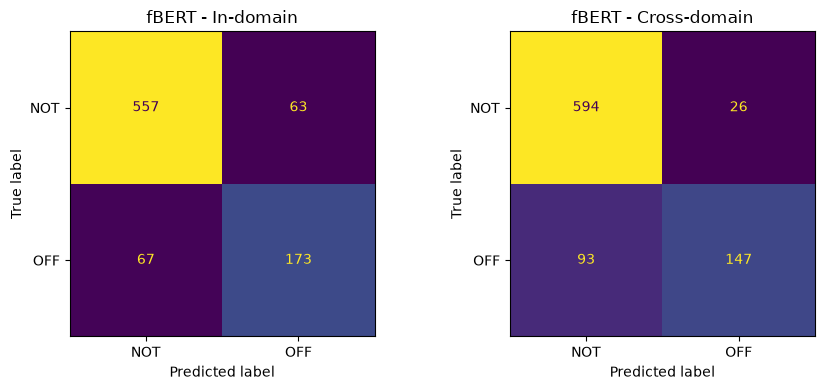

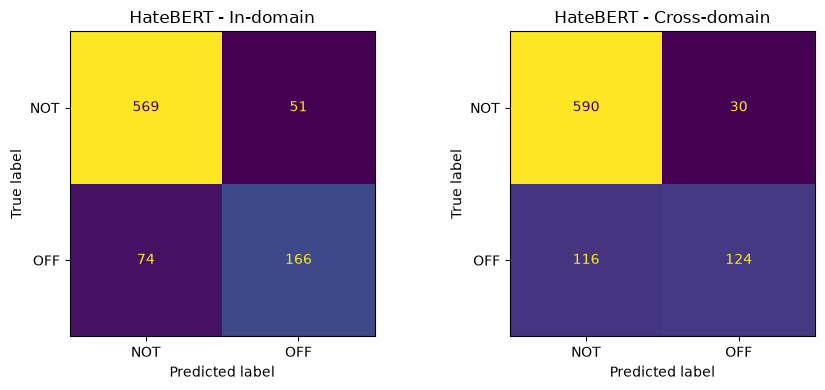

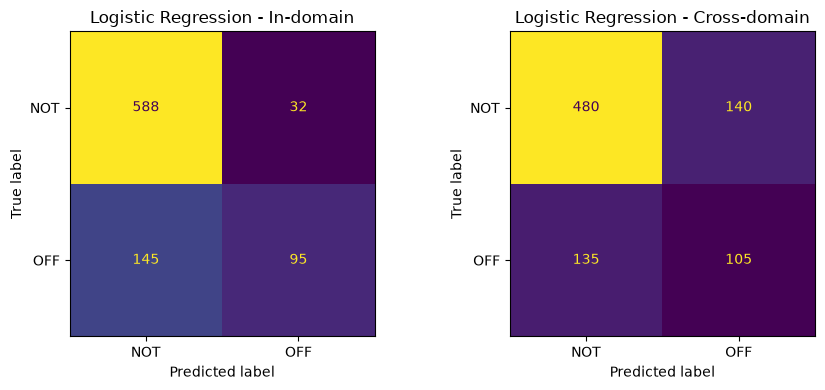

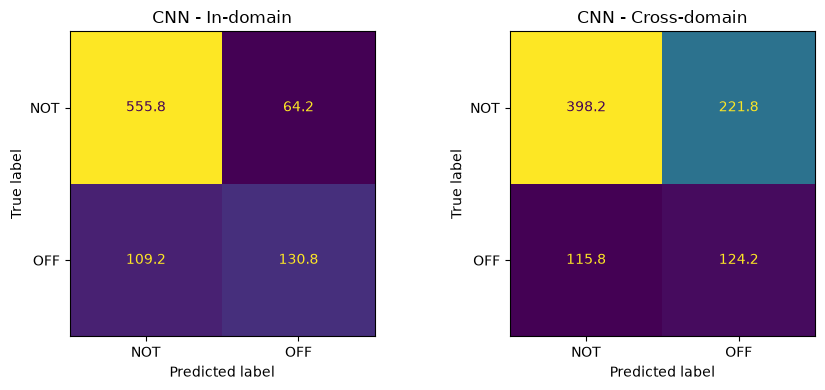

In [14]:
for name, (_, _, cm_olid, cm_hasoc) in MODELS.items():
    file_name = name.lower().replace(" ", "_")
    plot_confusion_matrices(
        cm_olid,
        cm_hasoc,
        name,
        f"figures/{file_name}_confusion_matrices.pdf",
        values_format=".1f" if name == "CNN" else "d"
    )

In [15]:
error_rows = []
for name, (_, _, cm_olid, cm_hasoc) in MODELS.items():
    error_rows.append({
        "Model": name,
        "In-domain FP": cm_olid[0, 1],
        "In-domain FN": cm_olid[1, 0],
        "Cross-domain FP": cm_hasoc[0, 1],
        "Cross-domain FN": cm_hasoc[1, 0]
    })

pd.DataFrame(error_rows).set_index("Model")

,In-domain FP,In-domain FN,Cross-domain FP,Cross-domain FN
Model,,,,
fBERT,63.0,67.0,26.0,93.0
HateBERT,51.0,74.0,30.0,116.0
Logistic Regression,32.0,145.0,140.0,135.0
CNN,64.2,109.2,221.8,115.8


## Error analysis

In [16]:
y = olid_test["labels"].values

# predictions[(model, setup)] has shape (runs, test tweets); only the CNN has more than one run
predictions = {
    ("fbert", "in"): fb_olid_results["prediction"].values[None],
    ("fbert", "cross"): fb_hasoc_results["prediction"].values[None],
    ("hatebert", "in"): hb_olid_results["prediction"].values[None],
    ("hatebert", "cross"): hb_hasoc_results["prediction"].values[None],
    ("lr", "in"): lr_olid_results["prediction"].values[None],
    ("lr", "cross"): lr_hasoc_results["prediction"].values[None],
    ("cnn", "in"): np.stack([run["prediction"].values for run in cnn_olid_runs]),
    ("cnn", "cross"): np.stack([run["prediction"].values for run in cnn_hasoc_runs]),
}
ANALYSIS_MODELS = ["fbert", "hatebert", "lr", "cnn"]

# Swear words and common insults, used to split tweets into explicit and implicit ones
EXPLICIT = re.compile(
    r"\b(?:fuck\w*|f\*+k\w*|shit\w*|bitch\w*|ass|asses|asshole\w*|arse\w*|damn\w*|crap\w*"
    r"|dick\w*|cunt\w*|bastard\w*|piss\w*|whore\w*|slut\w*|idiot\w*|stupid\w*|moron\w*"
    r"|dumb\w*|retard\w*|scum\w*|pussy|cock\w*|twat\w*|douche\w*|jackass\w*|loser\w*"
    r"|hoe|hoes|nigga\w*|nigger\w*|fag\w*|bullshit)\b",
    re.IGNORECASE
)

length = olid_test["text"].str.split().str.len().values
cut_short, cut_long = np.quantile(length, [1 / 3, 2 / 3])
explicit = olid_test["text"].str.contains(EXPLICIT).values
has_user = olid_test["text"].str.contains("@USER").values
has_url = olid_test["text"].str.contains(r"\bURL\b").values

GROUPS = {
    f"short (<= {cut_short:.0f} words)": length <= cut_short,
    "medium": (length > cut_short) & (length <= cut_long),
    f"long (> {cut_long:.0f} words)": length > cut_long,
    "with @USER": has_user,
    "without @USER": ~has_user,
    "with URL": has_url,
    "without URL": ~has_url,
    "explicit": explicit,
    "implicit": ~explicit,
}


def rate(model, setup, mask, label):
    # Share of test tweets with gold `label` in `mask` that are predicted as OFF (mean over runs)
    runs = predictions[(model, setup)]
    return np.mean([((y == label) & mask & (p == 1)).sum() / ((y == label) & mask).sum() for p in runs])


rows = []
for group, mask in GROUPS.items():
    row = {"group": group, "n OFF": ((y == 1) & mask).sum(), "n NOT": ((y == 0) & mask).sum()}
    for model in ANALYSIS_MODELS:
        row[f"{model} OFF recall"] = f"{rate(model, 'in', mask, 1):.3f} -> {rate(model, 'cross', mask, 1):.3f}"
        row[f"{model} FP rate"] = f"{rate(model, 'in', mask, 0):.3f} -> {rate(model, 'cross', mask, 0):.3f}"
    rows.append(row)

pd.DataFrame(rows).set_index("group").T

group,short (<= 16 words),medium,long (> 30 words),with @USER,without @USER,with URL,without URL,explicit,implicit
n OFF,99,76,65,80,160,111,129,89,151
n NOT,206,199,215,251,369,370,250,14,606
fbert OFF recall,0.758 -> 0.687,0.671 -> 0.487,0.723 -> 0.646,0.700 -> 0.550,0.731 -> 0.644,0.640 -> 0.523,0.791 -> 0.690,0.989 -> 0.978,0.563 -> 0.397
fbert FP rate,0.092 -> 0.029,0.075 -> 0.030,0.135 -> 0.065,0.120 -> 0.048,0.089 -> 0.038,0.073 -> 0.024,0.144 -> 0.068,0.929 -> 0.929,0.083 -> 0.021
hatebert OFF recall,0.758 -> 0.505,0.566 -> 0.474,0.738 -> 0.585,0.625 -> 0.500,0.725 -> 0.525,0.649 -> 0.459,0.729 -> 0.566,0.989 -> 0.753,0.517 -> 0.377
hatebert FP rate,0.068 -> 0.058,0.080 -> 0.035,0.098 -> 0.051,0.084 -> 0.068,0.081 -> 0.035,0.059 -> 0.022,0.116 -> 0.088,0.929 -> 0.500,0.063 -> 0.038
lr OFF recall,0.485 -> 0.495,0.289 -> 0.329,0.385 -> 0.477,0.325 -> 0.412,0.431 -> 0.450,0.261 -> 0.333,0.512 -> 0.527,0.719 -> 0.652,0.205 -> 0.311
lr FP rate,0.029 -> 0.175,0.040 -> 0.231,0.084 -> 0.270,0.048 -> 0.231,0.054 -> 0.222,0.027 -> 0.184,0.088 -> 0.288,0.429 -> 0.571,0.043 -> 0.218
cnn OFF recall,0.596 -> 0.564,0.463 -> 0.426,0.563 -> 0.554,0.465 -> 0.503,0.585 -> 0.525,0.423 -> 0.441,0.650 -> 0.583,0.854 -> 0.728,0.363 -> 0.393
cnn FP rate,0.067 -> 0.294,0.105 -> 0.375,0.138 -> 0.403,0.092 -> 0.361,0.111 -> 0.356,0.068 -> 0.326,0.157 -> 0.404,0.700 -> 0.714,0.090 -> 0.350


In [17]:
def share(df, pattern):
    has = df["text"].str.contains(pattern, case=False)
    return has.mean(), df.loc[has, "labels"].mean()


for name, df in datasets.items():
    off, not_ = df[df["labels"] == 1], df[df["labels"] == 0]
    print(f"{name}: explicit in {off['text'].str.contains(EXPLICIT).mean():.1%} of OFF "
          f"and {not_['text'].str.contains(EXPLICIT).mean():.1%} of NOT")

for pattern, label in [(r"#fucktrump", "#FuckTrump"), (r"\bshe\b", "'she'"), (r"\byou\b", "'you'")]:
    for name, df in datasets.items():
        frac, off_share = share(df, pattern)
        print(f"{label:11s} {name:19s}: in {frac:.1%} of messages, {off_share:.1%} of them OFF")

hatebert_tokenizer = AutoTokenizer.from_pretrained("GroNLP/hateBERT")
for text in ["#FuckTrump", "#Conservatives are #dumberthandogshit"]:
    print(text, "->", hatebert_tokenizer.tokenize(text))

OLID train (small): explicit in 31.7% of OFF and 3.0% of NOT
HASOC train: explicit in 45.6% of OFF and 27.3% of NOT
OLID test: explicit in 37.1% of OFF and 2.3% of NOT
#FuckTrump  OLID train (small) : in 0.0% of messages, nan% of them OFF
#FuckTrump  HASOC train        : in 19.3% of messages, 44.7% of them OFF
#FuckTrump  OLID test          : in 0.0% of messages, nan% of them OFF
'she'       OLID train (small) : in 12.7% of messages, 35.4% of them OFF
'she'       HASOC train        : in 2.1% of messages, 52.0% of them OFF
'she'       OLID test          : in 17.8% of messages, 18.3% of them OFF
'you'       OLID train (small) : in 27.0% of messages, 38.2% of them OFF
'you'       HASOC train        : in 20.2% of messages, 48.9% of them OFF
'you'       OLID test          : in 25.1% of messages, 25.0% of them OFF


#FuckTrump -> ['#', 'fuck', '##trum', '##p']
#Conservatives are #dumberthandogshit -> ['#', 'conservatives', 'are', '#', 'dumb', '##ert', '##hand', '##og', '##shi', '##t']


In [18]:
vocab = lr_hasoc.named_steps["tfidf"].get_feature_names_out()
coef = lr_hasoc.named_steps["classifier"].coef_[0]

print("Top OFF features (LR trained on HASOC):", list(vocab[np.argsort(coef)[::-1][:30]]))
print("Top NOT features (LR trained on HASOC):", list(vocab[np.argsort(coef)[:20]]))

# Words that push the cross-domain LR false positives towards OFF the most
contributions = lr_hasoc.named_steps["tfidf"].transform(olid_test["text"]).multiply(coef).tocsr()
false_positives = np.where((y == 0) & (predictions[("lr", "cross")][0] == 1))[0]
top_words = Counter()
for i in false_positives:
    row = contributions[i]
    top_words.update(vocab[row.indices[np.argsort(row.data)[::-1][:3]]])

print(f"\nMost frequent top-3 words in the {len(false_positives)} cross-domain LR false positives:")
print(top_words.most_common(15))
with_she = olid_test["text"].str.contains(r"\bshe\b", case=False).values
print(f"False positives containing 'she': {with_she[false_positives].sum()}")

Top OFF features (LR trained on HASOC): ['fuck', 'fucking', 'you', 'traitor', 'dickhead', 'shit', 'gandinaaliabuse', 'stupid', 'ass', 'trumpisadisgrace', 'council', 'sick', 'liar', 'president', 'racist', 'traitortrump', 'moron', 'your', 'father', 're', 'pm', 'com', 'pic', 'asshole', 'damn', 'borisjohnson', 'idiot', 'realdonaldtrump', 'need', 'orange']
Top NOT features (LR trained on HASOC): ['dhonikeepstheglove', 'doctorsfightback', 'shameonicc', 'doctors', 'dhoni', 'new', 'borisjohnsonshouldnotbepm', 'happy', 'resisttrump', 'real', 'indvaus', 'resist', 'indian', 'front', 'let', 'msdhoni', 'first', 'russia', 'shirt', 'both']

Most frequent top-3 words in the 140 cross-domain LR false positives:
[('you', 65), ('she', 47), ('is', 25), ('and', 25), ('your', 25), ('he', 22), ('as', 16), ('my', 10), ('need', 8), ('ever', 8), ('his', 6), ('or', 6), ('up', 5), ('get', 4), ('be', 4)]
False positives containing 'she': 50


In [19]:
def majority(model, setup):
    return (predictions[(model, setup)].mean(axis=0) >= 0.5).astype(int)


missed_cross = (y == 1) & np.all([majority(m, "cross") == 0 for m in ANALYSIS_MODELS], axis=0)
missed_in = (y == 1) & np.all([majority(m, "in") == 0 for m in ANALYSIS_MODELS], axis=0)
found_in_transformers = np.all([majority(m, "in") == 1 for m in ["fbert", "hatebert"]], axis=0)

print("OFF tweets missed by all four in-domain models:", missed_in.sum())
print("OFF tweets missed by all four cross-domain models:", missed_cross.sum())
print("... of which both in-domain transformers find:", (missed_cross & found_in_transformers).sum())
for text in olid_test.loc[missed_cross & found_in_transformers, "text"]:
    print("-", text)

lr_cnn_false_positives = (y == 0) & (majority("lr", "cross") == 1) & (majority("cnn", "cross") == 1) & with_she
print("\nCross-domain false positives of LR and CNN containing 'she' (first 5):")
for text in olid_test.loc[lr_cnn_false_positives, "text"].head(5):
    print("-", text)

OFF tweets missed by all four in-domain models: 48
OFF tweets missed by all four cross-domain models: 67
... of which both in-domain transformers find: 12
- @USER @USER @USER @USER @USER @USER @USER @USER @USER I’m shocked to learn human traffickers had guns.  Some probably illegal too.  CA needs more gun control.  But don’t worry about the actual crime.  The pic of black guns is worse.
- #Antifa: Take note of how to protest with civility.   This is why socialism (aka communism) will never win. It is inherently evil and unsustainable. URL
- #DregsOfSociety  ??? #Deplorables   Liberals usually dehumanize those they want to exterminate later URL
- #DrFord  #DearProfessorFord  Is a FRAUD Female @USER group paid for and organized by #GeorgeSoros URL
- #Democrat controlled city with strict gun control laws and @USER wants to blame the #GOP Um, isn’t it you rich #Democrats trying to keep the blacks in poverty? #WalkAway URL
- #CrowderConfronts continues to expose that the SJW bullies are pap